In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore') 

In [2]:
sp=pd.read_csv("C:/Users/sweth/Downloads/StudentsPerformance.csv") 
sp

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [3]:
sp.head() 

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
sp.tail() 

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
sp.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
print("Columns:",sp.columns) 

Columns: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [7]:
print("Shape:",sp.shape) 

Shape: (1000, 8)


In [8]:
sp.dtypes 

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [9]:
sp.isnull().sum() 

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course']

for col in cat_cols:
    le = LabelEncoder()
    sp[col] = le.fit_transform(sp[col]) 
    label_encoders[col] = le

print("Encoding completed successfully!")  

Encoding completed successfully!


In [11]:
for col, encoder in label_encoders.items():
    print(f"\n{col} Mapping:")
    print(dict(zip(encoder.classes_, 
                   encoder.transform(encoder.classes_))))


gender Mapping:
{'female': np.int64(0), 'male': np.int64(1)}

race/ethnicity Mapping:
{'group A': np.int64(0), 'group B': np.int64(1), 'group C': np.int64(2), 'group D': np.int64(3), 'group E': np.int64(4)}

parental level of education Mapping:
{"associate's degree": np.int64(0), "bachelor's degree": np.int64(1), 'high school': np.int64(2), "master's degree": np.int64(3), 'some college': np.int64(4), 'some high school': np.int64(5)}

lunch Mapping:
{'free/reduced': np.int64(0), 'standard': np.int64(1)}

test preparation course Mapping:
{'completed': np.int64(0), 'none': np.int64(1)}


In [12]:
#save the encoders
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [13]:
#verify they were saved
loaded_encoders = joblib.load("label_encoders.pkl") 

print(loaded_encoders.keys())

dict_keys(['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'])


In [14]:
sp.head() 

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [15]:
#columns
for col in cat_cols:
    print(f"\n{col}") 
    print(sp[col].value_counts()) 


gender
gender
0    518
1    482
Name: count, dtype: int64

race/ethnicity
race/ethnicity
2    319
3    262
1    190
4    140
0     89
Name: count, dtype: int64

parental level of education
parental level of education
4    226
0    222
2    196
5    179
1    118
3     59
Name: count, dtype: int64

lunch
lunch
1    645
0    355
Name: count, dtype: int64

test preparation course
test preparation course
1    642
0    358
Name: count, dtype: int64


In [16]:
X = sp.drop("math score", axis=1)
y = sp["math score"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape) 

X_train: (800, 7)
X_test : (200, 7)
y_train: (800,)
y_test : (200,)


In [17]:
#verify the class distribution
print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
math score
65    31
62    28
59    27
69    25
63    23
      ..
36     1
24     1
22     1
30     1
26     1
Name: count, Length: 77, dtype: int64

Testing Set
math score
73     8
62     7
69     7
45     7
61     6
71     6
58     6
67     6
49     6
85     5
77     5
75     5
68     5
79     5
65     5
66     5
51     5
81     5
59     5
55     4
56     4
60     4
87     4
64     4
54     4
84     4
76     4
74     4
80     4
82     3
88     3
70     3
53     3
63     3
48     3
78     3
90     2
29     2
50     2
57     2
40     2
46     2
44     1
91     1
19     1
41     1
93     1
27     1
33     1
0      1
100    1
28     1
83     1
37     1
89     1
34     1
36     1
43     1
30     1
52     1
Name: count, dtype: int64


In [18]:
print("Before:", sp.shape)

sp = sp.drop_duplicates()

print("After:", sp.shape) 

Before: (1000, 8)
After: (1000, 8)


In [19]:
from sklearn.preprocessing import StandardScaler
import joblib

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape) 

Feature scaling completed successfully!
Training Shape: (800, 7)
Testing Shape : (200, 7)


In [20]:
#Save and Verify Scaler

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

loaded_scaler = joblib.load("scaler.pkl") 
print(type(loaded_scaler)) 

Scaler saved successfully!
<class 'sklearn.preprocessing._data.StandardScaler'>


In [21]:
# Check class distribution
print("Class distribution in y_train:")
print(y_train.value_counts())

print("\nUnique classes:")
print(y_train.unique()) 

Class distribution in y_train:
math score
65    31
62    28
59    27
69    25
63    23
      ..
36     1
24     1
22     1
30     1
26     1
Name: count, Length: 77, dtype: int64

Unique classes:
[ 62  66  79  61  73  30  96  57  68  48  67  59  74  65  47  80  89  69
  53  64  82  36  90  52  51  63  40  46  77  99  70  42  97  50  43 100
  72  71  55  84  78  87  85  54  38  60  49  44  76  35  81  94  75  83
  98  92  93  88  32  39  86  41  58  22  56  95  24  37  18  91  45  23
  34  29  27   8  26]


In [22]:
# Linear Regression

from sklearn.linear_model import LinearRegression

# Initialize Linear Regression
linear_model = LinearRegression()

# Train Model 
linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
# Prediction

y_pred_linear = linear_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:") 
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_linear[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[77.11855699 57.07358    79.35766788 77.15093246 84.91283746 79.85882914
 64.42312794 52.47379147 74.61139924 50.01079481]


In [24]:
# Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear) 

mse_linear = mean_squared_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")

print("MAE  :", mae_linear)
print("MSE  :", mse_linear)
print("RMSE :", rmse_linear)
print("R2   :", r2_linear)

Linear Regression Results
MAE  : 4.130145078004057
MSE  : 28.275284506327363
RMSE : 5.317450940660136
R2   : 0.8838026201112222


In [25]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train Model
rf_model.fit(
    X_train_scaled,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
# Prediction

y_pred_rf = rf_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_rf[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[77.495 54.44  76.52  76.99  80.875 85.1   65.865 54.895 74.24  52.195]


In [27]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
 
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")

print("MAE  :", mae_rf)
print("MSE  :", mse_rf) 
print("RMSE :", rmse_rf)
print("R2   :", r2_rf)  

Random Forest Regression Results
MAE  : 4.689386904761904
MSE  : 36.7167824569161
RMSE : 6.059437470336343
R2   : 0.8491122549629812


In [28]:
# Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor

# Initialize Decision Tree
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Train Model
dt_model.fit(
    X_train_scaled,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [29]:
# Prediction

y_pred_dt = dt_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_dt[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[85. 42. 75. 75. 76. 88. 59. 54. 81. 64.]


In [30]:
# Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results")

print("MAE  :", mae_dt)
print("MSE  :", mse_dt)
print("RMSE :", rmse_dt)
print("R2   :", r2_dt)

Decision Tree Regression Results
MAE  : 5.985
MSE  : 60.595
RMSE : 7.784279028914624
R2   : 0.7509846370322152


In [31]:
# Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

# Initialize Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
gb_model.fit(
    X_train_scaled,
    y_train
)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [32]:
# Prediction

y_pred_gb = gb_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_gb[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[75.18102071 55.97978354 78.6602496  76.69617243 85.62954788 78.92414824
 65.6910181  53.61194104 75.27498252 49.83612856]


In [33]:
# Model Evaluation

mae_gb = mean_absolute_error(y_test, y_pred_gb)

mse_gb = mean_squared_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("------------------------------------")
print("MAE  :", mae_gb)
print("MSE  :", mse_gb)
print("RMSE :", rmse_gb)
print("R2   :", r2_gb)

Gradient Boosting Regression Results
------------------------------------
MAE  : 4.285368345517785
MSE  : 30.70150680058209
RMSE : 5.540894043435778
R2   : 0.8738320511658575


In [34]:
# Model Comparison
import pandas as pd
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_linear,
        mae_dt,
        mae_rf,
        mae_gb
    ],

    "MSE": [
        mse_linear,
        mse_dt,
        mse_rf,
        mse_gb
    ],

    "RMSE": [
        rmse_linear,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],

    "R2 Score": [
        r2_linear,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

print("Regression Model Comparison")

model_comparison

Regression Model Comparison


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.130145,28.275285,5.317451,0.883803
1,Decision Tree,5.985000,60.595000,7.784279,0.750985
2,Random Forest,4.689387,36.716782,6.059437,0.849112
3,Gradient Boosting,4.285368,30.701507,5.540894,0.873832


In [35]:
# Linear Regression Hyperparameter Tuning

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# Create Linear Regression model
lr = LinearRegression()

# Parameter Grid
lr_params = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

# Initialize GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train GridSearchCV
lr_grid.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression hyperparameter tuning completed!")

Linear Regression hyperparameter tuning completed!


In [36]:
# Best Parameters

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(lr_grid.best_score_)

Best Parameters:
{'fit_intercept': True, 'positive': True}

Best Cross-Validation R2 Score:
0.8573078896289935


In [37]:
# Best Linear Regression Model

best_lr_model = lr_grid.best_estimator_

print("Best Linear Regression model selected successfully!")
print(best_lr_model)

Best Linear Regression model selected successfully!
LinearRegression(positive=True)


In [38]:
# Prediction using Tuned Linear Regression

y_pred_lr_tuned = best_lr_model.predict(
    X_test_scaled
)

print("Prediction completed!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_lr_tuned[:10])

Prediction completed!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[77.11855699 57.07358    79.35766788 77.15093246 84.91283746 79.85882914
 64.42312794 52.47379147 74.61139924 50.01079481]


In [39]:
# Tuned Linear Regression Evaluation

mae_lr_tuned = mean_absolute_error(
    y_test,
    y_pred_lr_tuned
)

mse_lr_tuned = mean_squared_error(
    y_test,
    y_pred_lr_tuned
)

rmse_lr_tuned = np.sqrt(mse_lr_tuned)

r2_lr_tuned = r2_score(
    y_test,
    y_pred_lr_tuned
)

print("Tuned Linear Regression Results")
print("--------------------------------")
print("MAE  :", mae_lr_tuned)
print("MSE  :", mse_lr_tuned)
print("RMSE :", rmse_lr_tuned)
print("R2   :", r2_lr_tuned)

Tuned Linear Regression Results
--------------------------------
MAE  : 4.130145078004056
MSE  : 28.275284506327353
RMSE : 5.317450940660135
R2   : 0.8838026201112222


In [40]:
# Decision Tree Regression Hyperparameter Tuning

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Create Decision Tree model
dt = DecisionTreeRegressor(
    random_state=42
)

# Parameter Grid
dt_params = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

# Initialize GridSearchCV
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train GridSearchCV
dt_grid.fit(
    X_train_scaled,
    y_train
)

print("Decision Tree hyperparameter tuning completed!")

Decision Tree hyperparameter tuning completed!


In [41]:
# Best Parameters

print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(dt_grid.best_score_)

Best Parameters:
{'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation R2 Score:
0.8023727349003357


In [42]:
# Best Decision Tree Model

best_dt_model = dt_grid.best_estimator_

print("Best Decision Tree model selected successfully!")
print(best_dt_model)

Best Decision Tree model selected successfully!
DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42)


In [43]:
# Prediction using Tuned Decision Tree

y_pred_dt_tuned = best_dt_model.predict(
    X_test_scaled
)

print("Prediction completed!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_dt_tuned[:10])

Prediction completed!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[73.62222222 59.         75.4516129  75.4516129  83.33333333 83.33333333
 68.07142857 55.89830508 75.4516129  53.475     ]


In [44]:
# Tuned Decision Tree Evaluation

mae_dt_tuned = mean_absolute_error(
    y_test,
    y_pred_dt_tuned
)

mse_dt_tuned = mean_squared_error(
    y_test,
    y_pred_dt_tuned
)

rmse_dt_tuned = np.sqrt(mse_dt_tuned)

r2_dt_tuned = r2_score(
    y_test,
    y_pred_dt_tuned
)

print("Tuned Decision Tree Regression Results")
print("---------------------------------------")
print("MAE  :", mae_dt_tuned)
print("MSE  :", mse_dt_tuned)
print("RMSE :", rmse_dt_tuned)
print("R2   :", r2_dt_tuned)

Tuned Decision Tree Regression Results
---------------------------------------
MAE  : 4.936106543996105
MSE  : 42.85220060435656
RMSE : 6.54615922540512
R2   : 0.8238987327756057


In [45]:
# Random Forest Hyperparameter Tuning

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Initialize Random Forest
rf = RandomForestRegressor(
    random_state=42
) 

# Parameter Grid
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Initialize GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train GridSearchCV
rf_grid.fit(X_train_scaled,
            y_train)

print("Random Forest hyperparameter tuning completed!")

Random Forest hyperparameter tuning completed!


In [46]:
# Best Parameters

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation R2 Score:
0.8359611024181899


In [47]:
# Best Random Forest Model

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest model selected successfully!")
print(best_rf_model)

Best Random Forest model selected successfully!
RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_split=5,
                      random_state=42)


In [48]:
# Prediction using Tuned Random Forest

y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_rf_tuned[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[76.72893759 56.34826587 76.87986905 75.15736111 84.21086039 76.99737302
 64.42287807 55.20692857 72.29977381 52.41141667]


In [49]:
# Tuned Random Forest Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf_tuned = mean_absolute_error(
    y_test,
    y_pred_rf_tuned
)

mse_rf_tuned = mean_squared_error(
    y_test,
    y_pred_rf_tuned
)

rmse_rf_tuned = np.sqrt(mse_rf_tuned)

r2_rf_tuned = r2_score(
    y_test,
    y_pred_rf_tuned
)

print("Tuned Random Forest Regression Results")
print("--------------------------------------")
print("MAE  :", mae_rf_tuned)
print("MSE  :", mse_rf_tuned)
print("RMSE :", rmse_rf_tuned)
print("R2   :", r2_rf_tuned) 

Tuned Random Forest Regression Results
--------------------------------------
MAE  : 4.867753832140082
MSE  : 39.96408125880489
RMSE : 6.32171505675516
R2   : 0.8357674692576063


In [50]:
# Gradient Boosting Hyperparameter Tuning

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Initialize Gradient Boosting
gb = GradientBoostingRegressor(
    random_state=42
)

# Parameter Grid
gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize GridSearchCV
gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train GridSearchCV
gb_grid.fit(
    X_train_scaled,
    y_train
)

print("Gradient Boosting hyperparameter tuning completed!")

Gradient Boosting hyperparameter tuning completed!


In [51]:
# Best Parameters

print("Best Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation R2 Score:")
print(gb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Best Cross-Validation R2 Score:
0.8514328848154719


In [52]:
# Best Gradient Boosting Model

best_gb_model = gb_grid.best_estimator_

print("Best Gradient Boosting model selected successfully!")
print(best_gb_model)

Best Gradient Boosting model selected successfully!
GradientBoostingRegressor(learning_rate=0.05, max_depth=2, min_samples_split=10,
                          n_estimators=300, random_state=42)


In [53]:
# Prediction using Tuned Gradient Boosting

y_pred_gb_tuned = best_gb_model.predict(X_test_scaled)

print("Prediction completed successfully!")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred_gb_tuned[:10])

Prediction completed successfully!

First 10 Actual Values:
[91 53 80 74 84 81 69 54 87 51]

First 10 Predicted Values:
[76.16575401 57.48959063 79.40332257 76.92644511 86.86892559 78.5736207
 65.96790576 54.09716265 75.97108982 50.428914  ]


In [54]:
# Tuned Gradient Boosting Evaluation

mae_gb_tuned = mean_absolute_error(
    y_test,
    y_pred_gb_tuned
)

mse_gb_tuned = mean_squared_error(
    y_test,
    y_pred_gb_tuned
)

rmse_gb_tuned = np.sqrt(mse_gb_tuned)

r2_gb_tuned = r2_score(
    y_test,
    y_pred_gb_tuned
)

print("Tuned Gradient Boosting Regression Results")
print("------------------------------------------")
print("MAE  :", mae_gb_tuned)
print("MSE  :", mse_gb_tuned)
print("RMSE :", rmse_gb_tuned)
print("R2   :", r2_gb_tuned)

Tuned Gradient Boosting Regression Results
------------------------------------------
MAE  : 4.151305073617439
MSE  : 28.919871937893085
RMSE : 5.377719957183814
R2   : 0.8811536858223237


In [55]:
#model Comparison
import pandas as pd
model_comparison = pd.DataFrame({
    "Model": [
        "Tuned Linear Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],

    "MAE": [
        mae_lr_tuned,
        mae_dt_tuned,
        mae_rf_tuned,
        mae_gb_tuned
    ],

    "MSE": [
        mse_lr_tuned,
        mse_dt_tuned,
        mse_rf_tuned,
        mse_gb_tuned
    ],

    "RMSE": [
        rmse_lr_tuned,
        rmse_dt_tuned,
        rmse_rf_tuned,
        rmse_gb_tuned
    ],

    "R2 Score": [
        r2_lr_tuned,
        r2_dt_tuned,
        r2_rf_tuned,
        r2_gb_tuned
    ]
})

print("Tuned Regression Model Comparison")

model_comparison

Tuned Regression Model Comparison


,Model,MAE,MSE,RMSE,R2 Score
0,Tuned Linear Regression,4.130145,28.275285,5.317451,0.883803
1,Tuned Decision Tree,4.936107,42.852201,6.546159,0.823899
2,Tuned Random Forest,4.867754,39.964081,6.321715,0.835767
3,Tuned Gradient Boosting,4.151305,28.919872,5.377720,0.881154


In [56]:
# Actual vs Predicted Values

import pandas as pd

comparison = pd.DataFrame({
    "Actual Math Score": y_test.values,
    "Predicted Math Score": y_pred_linear
})

print(comparison.head(10))

   Actual Math Score  Predicted Math Score
0                 91             77.118557
1                 53             57.073580
2                 80             79.357668
3                 74             77.150932
4                 84             84.912837
5                 81             79.858829
6                 69             64.423128
7                 54             52.473791
8                 87             74.611399
9                 51             50.010795


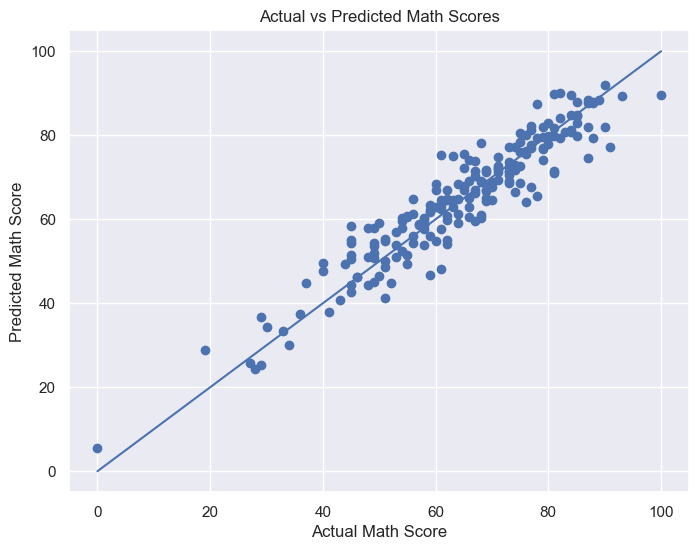

In [57]:
# Actual vs Predicted Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score") 
plt.title("Actual vs Predicted Math Scores")

# Perfect prediction line
plt.plot( 
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [58]:
# Final Model
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X_train_scaled, y_train)

# Final predictions
y_pred_final = final_model.predict(X_test_scaled)

print("Final Linear Regression model trained successfully!")

Final Linear Regression model trained successfully!


In [59]:
# Save Final Model and Scaler

import joblib

# Save the final Linear Regression model
joblib.dump(final_model, "student_math_score_model.pkl")

# Save the scaler
joblib.dump(scaler, "student_math_score_scaler.pkl")

print("Final model saved successfully!") 
print("Scaler saved successfully!")

Final model saved successfully!
Scaler saved successfully!


In [60]:
# Check Saved Files

import os

print("Model file exists:", os.path.exists("student_math_score_model.pkl"))
print("Scaler file exists:", os.path.exists("student_math_score_scaler.pkl"))

Model file exists: True
Scaler file exists: True
